# Assignment 2

In [2]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

---
## Q1 - Gini Index

### i. Gini index for Gender

In [3]:
total = 20

# Male: 10 examples (6 C0, 4 C1)
male_total = 10
male_C0 = 6
male_C1 = 4

# Female: 10 examples (4 C0, 6 C1)
female_total = 10
female_C0 = 4
female_C1 = 6

# Gini formula: 1 - (p_C0)^2 - (p_C1)^2
gini_male   = 1 - (male_C0/male_total)**2     - (male_C1/male_total)**2
gini_female = 1 - (female_C0/female_total)**2 - (female_C1/female_total)**2

print("Gini(Male)  =", round(gini_male, 4))
print("Gini(Female)=", round(gini_female, 4))

# Weighted Gini for Gender
gini_gender = (male_total/total) * gini_male + (female_total/total) * gini_female
print("\nGini(Gender) =", round(gini_gender, 4))

Gini(Male)  = 0.48
Gini(Female)= 0.48

Gini(Gender) = 0.48


### ii. Gini index for Car Type (multiway split)

In [4]:
# Family: 4 examples (1 C0, 3 C1)
family_total = 4
family_C0 = 1
family_C1 = 3

# Sports: 9 examples (9 C0, 0 C1)
sports_total = 9
sports_C0 = 9
sports_C1 = 0

# Luxury: 7 examples (0 C0, 7 C1)
luxury_total = 7
luxury_C0 = 0
luxury_C1 = 7

gini_family = 1 - (family_C0/family_total)**2 - (family_C1/family_total)**2
gini_sports = 1 - (sports_C0/sports_total)**2 - (sports_C1/sports_total)**2
gini_luxury = 1 - (luxury_C0/luxury_total)**2 - (luxury_C1/luxury_total)**2

print("Gini(Family) =", round(gini_family, 4))
print("Gini(Sports) =", round(gini_sports, 4))
print("Gini(Luxury) =", round(gini_luxury, 4))

# Weighted Gini for Car Type
gini_cartype = (family_total/total)*gini_family + (sports_total/total)*gini_sports + (luxury_total/total)*gini_luxury
print("\nGini(Car Type) =", round(gini_cartype, 4))

Gini(Family) = 0.375
Gini(Sports) = 0.0
Gini(Luxury) = 0.0

Gini(Car Type) = 0.075


### iii. Gini index for Shirt Size (multiway split)

In [5]:
# mall: 4 examples (3 C0, 1 C1)
small_total = 4
small_C0 = 3
small_C1 = 1

# Medium: 7 examples (3 C0, 4 C1)
medium_total = 7
medium_C0 = 3
medium_C1 = 4

# Large: 4 examples (2 C0, 2 C1)
large_total = 4
large_C0 = 2
large_C1 = 2

# Extra Large: 5 examples (2 C0, 3 C1)
xl_total = 5
xl_C0 = 2
xl_C1 = 3

gini_small  = 1 - (small_C0/small_total)**2  - (small_C1/small_total)**2
gini_medium = 1 - (medium_C0/medium_total)**2 - (medium_C1/medium_total)**2
gini_large  = 1 - (large_C0/large_total)**2  - (large_C1/large_total)**2
gini_xl     = 1 - (xl_C0/xl_total)**2        - (xl_C1/xl_total)**2

print("Gini(Small)       =", round(gini_small, 4))
print("Gini(Medium)      =", round(gini_medium, 4))
print("Gini(Large)       =", round(gini_large, 4))
print("Gini(Extra Large) =", round(gini_xl, 4))

# Weighted Gini for Shirt Size
gini_shirtsize = (small_total/total)*gini_small + (medium_total/total)*gini_medium + (large_total/total)*gini_large + (xl_total/total)*gini_xl
print("\nGini(Shirt Size) =", round(gini_shirtsize, 4))

Gini(Small)       = 0.375
Gini(Medium)      = 0.4898
Gini(Large)       = 0.5
Gini(Extra Large) = 0.48

Gini(Shirt Size) = 0.4664


### iv. Which attribute is best?

In [6]:
print("Gini(Gender)    =", round(gini_gender, 4))
print("Gini(Car Type)  =", round(gini_cartype, 4))
print("Gini(Shirt Size)=", round(gini_shirtsize, 4))

print()
print("Best attribute: Car Type")
print("Reason: Car Type has the lowest Gini index, which means it produces")
print("the purest splits. A lower Gini index = less impurity = better split.")

Gini(Gender)    = 0.48
Gini(Car Type)  = 0.075
Gini(Shirt Size)= 0.4664

Best attribute: Car Type
Reason: Car Type has the lowest Gini index, which means it produces
the purest splits. A lower Gini index = less impurity = better split.


---
## Q2 - Decision Tree Classification

### i. Classify each test example

In [7]:
# Test set
test_set = [
    [1, 0, 1, 0, '+'],
    [2, 0, 1, 1, '+'],
    [3, 0, 0, 0, '+'],
    [4, 0, 0, 1, '-'],
    [5, 1, 0, 0, '-'],
    [6, 1, 0, 1, '-'],
    [7, 1, 1, 0, '-'],
    [8, 1, 1, 1, '-'],
]

print(f"{'ID':<5} {'A':<5} {'B':<5} {'C':<5} {'True Label':<12} {'Predicted':<10}")
print("-" * 45)

true_labels  = []
predictions  = []

for row in test_set:
    ID, A, B, C, label = row

    if A == 0:
        if B == 0:
            predicted = '+'
        else:
            predicted = '-'
    else:
        if C == 0:
            predicted = '-'
        else:
            predicted = '+'

    true_labels.append(label)
    predictions.append(predicted)
    print(f"{ID:<5} {A:<5} {B:<5} {C:<5} {label:<12} {predicted:<10}")

ID    A     B     C     True Label   Predicted 
---------------------------------------------
1     0     1     0     +            -         
2     0     1     1     +            -         
3     0     0     0     +            +         
4     0     0     1     -            +         
5     1     0     0     -            -         
6     1     0     1     -            +         
7     1     1     0     -            -         
8     1     1     1     -            +         


### ii. Confusion Matrix

  TP = 1  (predicted + and actually +)
  FP = 3  (predicted + but actually -)
  TN = 2  (predicted - and actually -)
  FN = 2  (predicted - but actually +)


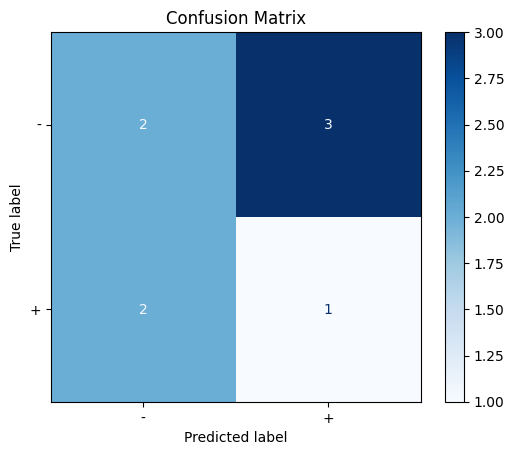

In [8]:
# confusion_matrix returns [[TN, FP], [FN, TP]] when positive class is listed second
cm = confusion_matrix(true_labels, predictions, labels=['-', '+'])

TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print(f"  TP = {TP}  (predicted + and actually +)")
print(f"  FP = {FP}  (predicted + but actually -)")
print(f"  TN = {TN}  (predicted - and actually -)")
print(f"  FN = {FN}  (predicted - but actually +)")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['-', '+'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

### iii. Accuracy, Precision, Recall, F1

In [9]:
accuracy  = accuracy_score(true_labels, predictions)
precision = precision_score(true_labels, predictions, pos_label='+')
recall    = recall_score(true_labels, predictions, pos_label='+')
f1        = f1_score(true_labels, predictions, pos_label='+')

print("Accuracy  =", round(accuracy, 4))
print("Precision =", round(precision, 4))
print("Recall    =", round(recall, 4))
print("F1        =", round(f1, 4))

Accuracy  = 0.375
Precision = 0.25
Recall    = 0.3333
F1        = 0.2857


---
## Q3 - kNN Classification

### Setup: Training and test data

In [10]:
# training dataset from Figure (A)
X_train = [
    [4.6, 3.2, 1.4, 0.2],
    [6.7, 3.1, 4.4, 1.4],
    [6.3, 3.4, 5.6, 2.4],
    [6.4, 2.9, 4.3, 1.3],
    [5.0, 2.0, 3.5, 1.0],
    [4.6, 3.6, 1.0, 0.2],
    [5.8, 2.7, 5.1, 1.9],
    [4.8, 3.0, 1.4, 0.3],
    [7.1, 3.0, 5.9, 2.1],
    [6.3, 2.9, 5.6, 1.8],
    [5.7, 4.4, 1.5, 0.4],
    [6.9, 3.1, 4.9, 1.5],
]

y_train = [
    'Setosa',
    'Versicolor',
    'Virginica',
    'Versicolor',
    'Versicolor',
    'Setosa',
    'Virginica',
    'Setosa',
    'Virginica',
    'Virginica',
    'Setosa',
    'Versicolor',
]

# test dataset from Figure (B)
X_test = [
    [4.6, 3.4, 1.4, 0.3],  # Test Example 0
    [5.7, 2.9, 4.2, 1.3],  # Test Example 1
    [5.9, 3.0, 5.1, 1.8],  # Test Example 2
]

### Part i - k = 1

In [11]:
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train, y_train)

predictions_k1 = knn1.predict(X_test)

print("k=1 Predictions:")
for i, pred in enumerate(predictions_k1):
    print(f"  Test Example {i}: {pred}")

k=1 Predictions:
  Test Example 0: Setosa
  Test Example 1: Versicolor
  Test Example 2: Virginica


### Part ii - k = 3

In [12]:
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train, y_train)

predictions_k3 = knn3.predict(X_test)

# kneighbors() returns the distances and indices of the 3 nearest neighbors
neighbor_distances, neighbor_indices = knn3.kneighbors(X_test)

print("k=3 Predictions:")
for i, pred in enumerate(predictions_k3):
    print(f"  Test Example {i}: {pred}")
    for j in range(3):
        idx  = neighbor_indices[i][j]
        dist = neighbor_distances[i][j]
        print(f"    Neighbor {j+1}: Train Example {idx} (distance={round(dist,2)}, label={y_train[idx]})")

k=3 Predictions:
  Test Example 0: Setosa
    Neighbor 1: Train Example 0 (distance=0.22, label=Setosa)
    Neighbor 2: Train Example 7 (distance=0.45, label=Setosa)
    Neighbor 3: Train Example 5 (distance=0.46, label=Setosa)
  Test Example 1: Versicolor
    Neighbor 1: Train Example 3 (distance=0.71, label=Versicolor)
    Neighbor 2: Train Example 1 (distance=1.04, label=Versicolor)
    Neighbor 3: Train Example 6 (distance=1.1, label=Virginica)
  Test Example 2: Virginica
    Neighbor 1: Train Example 6 (distance=0.33, label=Virginica)
    Neighbor 2: Train Example 9 (distance=0.65, label=Virginica)
    Neighbor 3: Train Example 2 (distance=0.96, label=Virginica)
